# 5장 실습 — GTFS 시간표 열어 보기

버스는 아무 때나 출발하지 않습니다. 시간표에 적힌 시각에만 출발합니다.
그 시간표는 GTFS 라는 공통 형식으로 배포됩니다. 교재 5장에 대응합니다.

이 노트북에서 하는 일은 넷입니다.

1. 표 다섯 개를 열어 보고 서로 어떻게 이어지는지 봅니다 (교재 5.1)
2. 한국 데이터에서 걸려 넘어지는 두 곳을 확인합니다 (교재 5.2, 5.3)
3. 정류장을 지도에 찍고, 경계로 잘라 봅니다 (교재 5.4, 5.5)
4. 빈칸 세 개를 채웁니다

기말 프로젝트에서 여러분이 고른 시군구의 GTFS 를 자를 때 이 절차를 그대로 씁니다.

In [ ]:
import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "smartmob").is_dir())
sys.path[:0] = [str(ROOT), str(ROOT / "labs")]

from lab import banner, expect, todo
from smartmob.viz import use_korean_font

use_korean_font()

'Malgun Gothic'

## 1. 표 다섯 개 (교재 5.1)

`load_gtfs("hanam")` 은 하남시를 지나는 노선의 GTFS 를 표(DataFrame) 다섯 개가 든 사전으로 돌려줍니다.
`describe_feed` 는 표마다 행 수를 세고, 노선을 수단별로 헤아려 줍니다.

In [ ]:
from smartmob.data import describe_feed, load_gtfs

feed = load_gtfs("hanam")
describe_feed(feed)

{'stops': 4203,
 'routes': 169,
 'trips': 8923,
 'stop_times': 656385,
 'route_type': {'시내·농어촌·마을버스': 132,
  '도시철도': 15,
  '시외버스': 4,
  '일반철도': 6,
  '공항리무진': 8,
  '고속철도': 4}}

정류장 4,203개, 노선 169개, 운행 8,923개, 시각표 656,385행입니다.
어느 표에 어떤 컬럼이 있는지도 봐 둡니다. 앞으로 이 컬럼 이름으로 표를 잇습니다.

In [ ]:
for name, table in feed.items():
    print(f"{name:12s} {len(table):>8,}행   {list(table.columns)[:6]}")

stops           4,203행   ['stop_id', 'stop_name', 'stop_lat', 'stop_lon']
routes            169행   ['route_id', 'agency_id', 'route_short_name', 'route_long_name', 'route_type', 'route_color']
trips           8,923행   ['route_id', 'service_id', 'trip_id', 'shape_id']
stop_times    656,385행   ['trip_id', 'arrival_time', 'departure_time', 'stop_id', 'stop_sequence', 'pickup_type']
calendar            1행   ['service_id', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday']


표 사이의 연결은 이렇습니다.

```
routes      노선     "340번 버스"                       route_id
  ↓
trips       운행     "340번의 오전 7시 12분 차"           trip_id
  ↓
stop_times  시각표   "그 차가 각 정류장에 몇 시에 서는가"   stop_id, stop_sequence
  ↓
stops       정류장   "그 정류장의 이름과 위경도"
```

노선과 운행이 다르다는 점이 중요합니다. 340번은 노선 하나이지만 하루에 수십 번 다니고, 그 한 번 한 번이 운행입니다.
`stop_times` 는 운행 하나가 정류장을 지나는 순서(`stop_sequence`)대로 도착·출발 시각을 적은 표입니다.

In [ ]:
feed["stop_times"].head()

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,pickup_type,drop_off_type,timepoint
0,BR_1100_100100055_Ord001,04:30:00,04:30:00,BS_1100_124000344,1,0,1,1
1,BR_1100_100100055_Ord001,04:30:19,04:30:29,BS_1100_124000429,2,0,0,1
2,BR_1100_100100055_Ord001,04:31:25,04:31:35,BS_1100_124000211,3,0,0,1
3,BR_1100_100100055_Ord001,04:32:09,04:32:19,BS_1100_124000206,4,0,0,1
4,BR_1100_100100055_Ord001,04:32:53,04:33:03,BS_1100_124000210,5,0,0,1


노선 하나에 운행이 몇 개나 달리는지 세어 봅니다.
`groupby("route_id").size()` 는 `trips` 를 노선별로 묶고 각 묶음의 행 수, 즉 운행 수를 돌려줍니다.

In [ ]:
trips_per_route = feed["trips"].groupby("route_id").size()    # 노선별 운행 수 (Series)

print(f"노선 {len(trips_per_route)}개")
print(f"노선당 운행 수  중앙값 {trips_per_route.median():.0f}회, 최대 {trips_per_route.max()}회")

노선 169개
노선당 운행 수  중앙값 36회, 최대 293회


가장 많이 다니는 노선은 하루 293회입니다. 3분에 한 대꼴입니다.

## 2. route_type 이 국제 표준과 다릅니다 (교재 5.2)

`routes` 의 `route_type` 이 수단을 나타냅니다. GTFS 국제 명세로는 0=트램, 1=지하철, 2=철도, 3=버스입니다.
한국 데이터는 국토교통부 TAGO 코드를 씁니다. 코드별로 노선이 몇 개인지 세고 `KOREAN_ROUTE_TYPE` 으로 이름을 붙입니다.

In [ ]:
from smartmob.data import KOREAN_ROUTE_TYPE

counts = feed["routes"]["route_type"].astype(int).value_counts().sort_index()   # 코드별 노선 수
for code, n in counts.items():
    print(f"{code:3d}  {KOREAN_ROUTE_TYPE.get(int(code), '기타'):10s} {n:4d}개 노선")

  0  시내·농어촌·마을버스  132개 노선
  1  도시철도         15개 노선
  3  시외버스          4개 노선
  4  일반철도          6개 노선
  5  공항리무진         8개 노선
  6  고속철도          4개 노선


0 이 132개로 가장 많습니다. 국제 명세대로 읽으면 하남에 트램 노선이 132개 있다는 뜻이 되지만, TAGO 코드에서 0 은 시내·농어촌·마을버스입니다.
국제 명세대로 `route_type == 3` 을 버스로 걸러 내면 시외버스 4개만 남고, 코드는 오류 없이 돌아갑니다. 결과 숫자가 이상해야 알아차립니다.

## 3. 시각이 24시를 넘습니다 (교재 5.3)

밤 11시 50분에 출발해 새벽 0시 20분에 도착하는 버스를 `00:20:00` 으로 적으면 도착이 출발보다 이른 시각이 됩니다.
그래서 GTFS 는 `24:20:00` 처럼 24를 넘겨 적습니다. 그런 행이 몇 개인지 세어 봅니다.
`str.slice(0, 2)` 는 `"25:10:00"` 에서 앞 두 글자 `"25"` 만 잘라 냅니다.

In [ ]:
from smartmob.data import parse_gtfs_time, seconds_to_gtfs_time

late = feed["stop_times"]["departure_time"].astype(str)
over_24 = late[late.str.slice(0, 2).astype(int) >= 24]        # "HH" 부분이 24 이상인 행

print(f"24시를 넘는 시각 {len(over_24):,}건")
print(over_24.head(5).tolist())

24시를 넘는 시각 22,560건
['24:00:25', '24:01:00', '24:02:05', '24:02:58', '24:00:38']


22,560건이 24시를 넘습니다. 이 문자열을 `datetime` 으로 파싱하면 오류가 납니다.
`parse_gtfs_time` 은 문자열을 자정부터의 초로 바꾸고, `seconds_to_gtfs_time` 은 거꾸로 되돌립니다. 24를 넘는 표기도 그대로 받습니다.

In [ ]:
for text in ["08:30:00", "24:05:00", "25:10:00"]:
    secs = parse_gtfs_time(text)
    print(f"{text}  →  {secs:6,}초  →  다시 {seconds_to_gtfs_time(secs)}")

08:30:00  →  30,600초  →  다시 08:30:00
24:05:00  →  86,700초  →  다시 24:05:00
25:10:00  →  90,600초  →  다시 25:10:00


`25:10:00` 은 90,600초입니다. 다음 날 새벽 1시 10분이지만 운행일은 전날 하나입니다. 6장에서 시각을 전부 이 초 단위로 다룹니다.

## 4. 정류장 지도 (교재 5.4)

정류장 4,203개를 위경도 그대로 찍습니다.
`set_aspect(1 / 0.79)` 는 위도 37도에서 경도 1도가 위도 1도보다 짧은 것을 보정합니다.

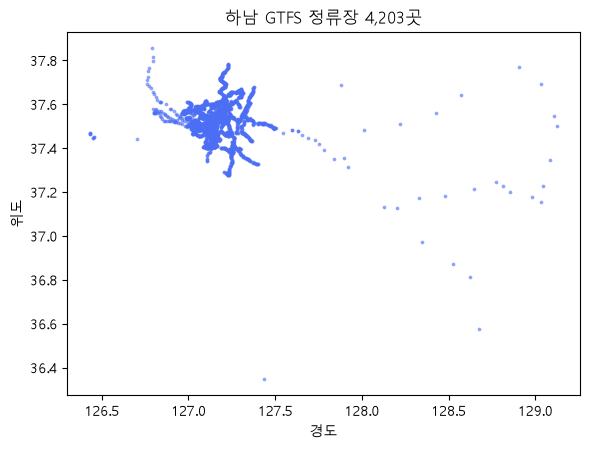

In [ ]:
import matplotlib.pyplot as plt

stops = feed["stops"]
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(stops["stop_lon"], stops["stop_lat"], s=3, alpha=0.5, color="#4C6EF5")
ax.set_xlabel("경도")
ax.set_ylabel("위도")
ax.set_title(f"하남 GTFS 정류장 {len(stops):,}곳")
ax.set_aspect(1 / 0.79)        # 위도 37도에서 경도 1도가 더 짧습니다
plt.tight_layout();

정류장이 하남 경계 밖까지 퍼져 있습니다. 하남을 지나는 노선의 정류장 전체가 들어 있기 때문입니다.
340번 버스가 서울 강변역까지 간다면 강변역 정류장도 함께 들어옵니다.

## 5. 잘라 낼 때 노선 전체를 남깁니다 (교재 5.5)

경계 안의 정류장만 남기면 노선이 경계에서 끊깁니다. 경계 안에 10개, 밖에 15개 정류장이 있는 노선은 10개짜리 노선이 됩니다.
그래서 정류장이 아니라 노선 단위로 남깁니다. 경계 안 정류장 → 그 정류장을 지나는 운행 → 그 운행의 노선 → 그 노선의 운행 전부, 이 순서입니다.

먼저 경계를 가져옵니다. `list_sigungu` 로 이름을 확인하고 `load_sigungu` 로 폴리곤을 읽습니다.

In [ ]:
from smartmob.data import clip_to_boundary, list_sigungu, load_sigungu

print(list_sigungu(contains="하남")[:5])

['하남시']


`clip_to_boundary` 가 위 순서대로 잘라 냅니다. `buffer_m=500` 은 경계 바깥 500m 까지를 경계 안으로 칩니다.
시 경계에서 30m 떨어진 정류장은 사실상 그 동네 정류장인데, 딱 잘라 내면 사라지기 때문입니다.

In [ ]:
boundary = load_sigungu("하남시")
clipped = clip_to_boundary(feed, boundary, buffer_m=500)

banner("경계로 자른 뒤")
before, after = describe_feed(feed), describe_feed(clipped)
for key in ["stops", "routes", "trips", "stop_times"]:
    print(f"{key:12s} {before[key]:>8,} → {after[key]:>8,}")

ModuleNotFoundError: No module named 'shapely'

정류장 4,203개가 4,128개로, 노선 169개가 167개로 줄었습니다.
하남 근처를 지나지 않는 노선 2개만 빠졌고, 남은 노선은 경계 밖 구간까지 통째로 남았습니다. 그래서 정류장이 조금밖에 줄지 않습니다.

## 6. 한 정류장을 지나는 노선 세어 보기 (교재 5.6)

빈칸을 채우기 전에 표를 잇는 연습을 한 번 합니다. 하남시청 정류장을 지나는 노선을 찾습니다.
순서는 5절과 같습니다. 정류장 → `stop_times` 에서 운행 → `trips` 에서 노선입니다.
`isin` 은 열의 값이 주어진 집합에 들어 있는지를 행마다 True/False 로 돌려줍니다.

In [ ]:
target = stops[stops["stop_name"].str.contains("하남시청", na=False)]
stop_ids = set(target["stop_id"])

st = feed["stop_times"]
trip_ids = set(st[st["stop_id"].isin(stop_ids)]["trip_id"])         # 그 정류장에 서는 운행

trips = feed["trips"]
route_ids = set(trips[trips["trip_id"].isin(trip_ids)]["route_id"])   # 그 운행이 속한 노선

here = feed["routes"][feed["routes"]["route_id"].isin(route_ids)]
print(f"이름에 '하남시청' 이 든 정류장 {len(target)}곳, 지나는 노선 {len(here)}개")
here[["route_short_name", "route_type"]].head(10)

`isin` 을 두 번 거쳐 정류장에서 노선까지 올라왔습니다. 빈칸 7.1 은 같은 표를 반대 방향으로 씁니다.

## 7. 빈칸

### 7.1 운행이 가장 많은 노선

`trips` 를 `route_id` 로 묶어 운행 횟수 상위 5개 노선을 찾습니다. 1절의 `trips_per_route` 를 그대로 써도 됩니다.
`routes` 와 합쳐 노선 이름(`route_short_name` 또는 `route_long_name`)도 함께 봅니다. 1위는 293회여야 합니다.

In [ ]:
busiest = None      # 상위 5개 노선 (DataFrame 또는 Series)

banner("빈칸 7.1")
todo("운행이 가장 많은 노선 5개", busiest, fmt=lambda x: f"{len(x)}개")

### 7.2 첫차와 막차

전체 `stop_times` 에서 가장 이른 출발 시각과 가장 늦은 출발 시각을 구합니다.
`parse_gtfs_time` 으로 초로 바꾼 뒤 비교해야 합니다. 문자열로 비교하면 `"25:10:00"` 이 `"08:00:00"` 보다 앞에 옵니다.
`late.map(parse_gtfs_time)` 처럼 쓰면 열의 값 하나하나에 함수를 적용한 새 열이 나옵니다.

In [ ]:
first_departure = None     # 가장 이른 출발 (초)
last_departure = None      # 가장 늦은 출발 (초)

banner("빈칸 7.2")
todo("첫차", first_departure, fmt=seconds_to_gtfs_time)
todo("막차", last_departure, fmt=seconds_to_gtfs_time)

### 7.3 우리 동네

`list_sigungu()` 에서 여러분이 사는 시군구를 찾아 이름을 적습니다.
P-실무프로젝트의 대상지가 될 곳입니다. 인구 20~50만 규모를 권합니다.

지금은 경계를 찾을 수 있는지만 확인합니다. 전국 GTFS 를 이 경계로 자르는 것은 프로젝트에서 합니다.

In [ ]:
my_sigungu = None      # 예: "성남시 수정구"

banner("빈칸 7.3")
if my_sigungu:
    info = load_sigungu(my_sigungu)
    print(f"[v] {my_sigungu} 경계를 찾았습니다")
else:
    print("[ ] my_sigungu 가 비어 있습니다. 후보:", list_sigungu()[:8], "...")

## 정리

- GTFS 는 표 다섯 개입니다. `routes` → `trips` → `stop_times` → `stops` 순으로 이어집니다
- 노선과 운행은 다릅니다. 하남에서 가장 많이 다니는 노선은 하루 293회입니다
- 한국 데이터의 `route_type` 은 TAGO 코드입니다. 0 이 시내버스이고 트램이 아닙니다
- 시각이 24시를 넘습니다. `parse_gtfs_time` 으로 초로 바꿔 다룹니다
- 경계로 자를 때는 정류장이 아니라 노선 전체를 남깁니다. 정류장 4,203개 중 4,128개가 남습니다
- 6장 실습에서는 이 시간표 위에서 환승 경로를 직접 찾습니다